In [1]:
import numpy as np
import cupy as cp
import numba as nb
import numba.cuda
import matplotlib.pyplot as plt
import geopandas as gpd
import shapely
import rasterio
import rasterio.warp
import skimage.feature
from tqdm.notebook import tqdm

This naive implementation of `convolve2d` on a GPU is 100× faster than SciPy's CPU-bound implementation.

The image is reflected at its boundaries, but we'll be cutting off affected regions, anyway.

In [3]:
_convolve2dkernel = {}

def convolve2d(image, kernel):
    image = cp.asarray(image, dtype=np.float32)
    kernel = cp.asarray(kernel, dtype=np.float32)
    output = cp.zeros_like(image)

    key = (image.shape, kernel.shape)
    if key not in _convolve2dkernel:
        imageI, imageJ = image.shape
        kernelI, kernelJ = kernel.shape

        @nb.cuda.jit
        def fcn(image, kernel, output):
            imi, imj = nb.cuda.grid(2)
            if imi >= imageI or imj >= imageJ:
                return

            halfi = kernelI // 2
            halfj = kernelJ // 2

            accumulate = 0
            for ki in range(kernelI):
                for kj in range(kernelJ):
                    i = imi + ki - halfi
                    j = imj + kj - halfj
                    # boundary conditions that reflect
                    if i < 0:
                        i = -i
                    if j < 0:
                        j = -j
                    if i > imageI:
                        i = 2*imageI - i
                    if j > imageJ:
                        j = 2*imageJ - j
                    accumulate += image[i, j] * kernel[ki, kj]

            output[imi, imj] = accumulate

        _convolve2dkernel[key] = fcn

    threadsperblock = (32, 32)
    blockspergrid_x = int(np.ceil(image.shape[0] / threadsperblock[0]))
    blockspergrid_y = int(np.ceil(image.shape[1] / threadsperblock[1]))
    blockspergrid = (blockspergrid_x, blockspergrid_y)

    _convolve2dkernel[key][blockspergrid, threadsperblock](image, kernel, output)
    return output.get()

The standard technique for finding gullies is "difference from mean elevation," which is equivalent to a convolution with a central peak of area 1 surrounded by a wide disk of area ‒1.

I'll be using this to define "local elevation" (elevation of meter-scale features with broad mountains subtracted out).

In [5]:
def disk(radius):
    radius = int(np.ceil(radius))
    width = 2 * radius + 1
    bigx, bigy = np.meshgrid(np.arange(10 * width), np.arange(10 * width))
    x = bigx / 10 - radius - 0.5
    y = bigy / 10 - radius - 0.5
    disk = x**2 + y**2 <= radius**2
    small_disk = np.sum(np.sum(disk.reshape((width, 10, width, 10)), axis=-1), axis=-2)
    return small_disk / np.sum(small_disk)

In [3]:
def point_in_disk(radius=50, linewidth=1):
    width = 2 * radius + 1
    bigx, bigy = np.meshgrid(np.arange(10 * width), np.arange(10 * width))
    x = bigx / 10 - radius - 0.5
    y = bigy / 10 - radius - 0.5
    disk = x**2 + y**2 <= radius**2
    minidisk = x**2 + y**2 <= linewidth**2
    small_disk = np.sum(np.sum(disk.reshape((width, 10, width, 10)), axis=-1), axis=-2)
    small_minidisk = np.sum(np.sum(minidisk.reshape((width, 10, width, 10)), axis=-1), axis=-2)
    small_disk[small_minidisk > 0] = 0
    small_disk = -small_disk / np.sum(small_disk)
    small_disk[small_minidisk > 0] = 1 / np.sum(small_minidisk > 0)
    return small_disk

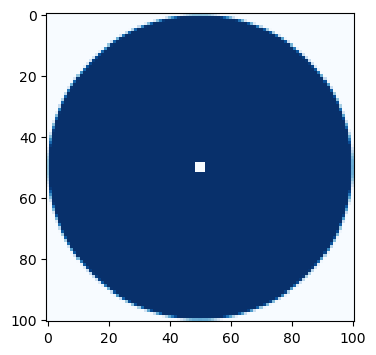

In [4]:
fig, ax = plt.subplots(figsize=(4, 4))

tmp = point_in_disk()
ax.imshow(tmp, vmin=np.nanmin(tmp), vmax=0, cmap="Blues_r")

None

My improvement on "difference from mean elevation" is a convolution kernel with a long, narrow shape. This lets our gully detection be sensitive to extended features (up to `2*linelength`, 40 meters) without blurring over the narrow channel.

However, it means that we need to compute the convolution for every increment of 11.25 degrees and find the minimum.

In [5]:
def line_in_disk(angle, radius=50, linelength=20, linewidth=1):
    width = 2 * radius + 1
    bigx, bigy = np.meshgrid(np.arange(10 * width), np.arange(10 * width))
    x = bigx / 10 - radius - 0.5
    y = bigy / 10 - radius - 0.5
    disk = x**2 + y**2 <= radius**2
    minidisk = x**2 + y**2 <= linelength**2
    line = np.abs(x * np.sin(-angle * np.pi/180) - y * np.cos(angle * np.pi/180)) < linewidth
    centerline = minidisk & line
    pill = disk & ~centerline

    shrink = lambda array: np.sum(np.sum(array.reshape((width, 10, width, 10)), axis=-1), axis=-2)
    small = shrink(pill)
    small_centerline = shrink(centerline)
    return -small / np.sum(small) + small_centerline / np.sum(small_centerline)

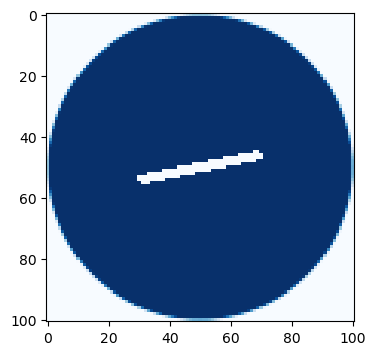

In [6]:
fig, ax = plt.subplots(figsize=(4, 4))

tmp = line_in_disk(11.25)
ax.imshow(tmp, vmin=np.nanmin(tmp), vmax=0, cmap="Blues_r")

None

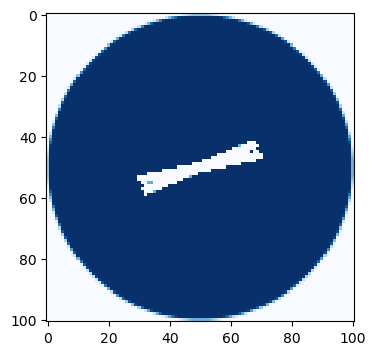

In [7]:
fig, ax = plt.subplots(figsize=(4, 4))

tmp1 = line_in_disk(11.25)
tmp2 = line_in_disk(22.50)
ax.imshow(tmp1 + tmp2, vmin=np.nanmin(tmp1 + tmp2), vmax=0, cmap="Blues_r")

None

Read the files. The 2022 data has 0.5-meter resolution, the 2013 data has 3-foot resolution, and they're in different coordinate systems, so we transform the 2013 data into the 2022 coordinate system (which upscales it). Bilinear interpolation is just as good as cubic.

In [7]:
with rasterio.open("../DutchBill-2022.tif") as file:
    elevation2022 = file.read(1)
    crs = file.crs
    transform = file.transform
    shape = (file.height, file.width)
    left, bottom, right, top = file.bounds

In [8]:
FEET_PER_METER = 3.28084

with rasterio.open("../DutchBill-2013.tif") as file:
    tmp_original = file.read(1)
    tmp_mask = tmp_original != -9999.0
    tmp_shrunk_mask = convolve2d(tmp_mask, disk(55 * FEET_PER_METER / 2))

    elevation2013 = np.empty(shape, dtype=elevation2022.dtype)
    rasterio.warp.reproject(
        source=tmp_original,
        destination=elevation2013,
        src_transform=file.transform,
        src_crs=file.crs,
        dst_transform=transform,
        dst_crs=crs,
        resampling=rasterio.warp.Resampling.bilinear,
    )
    elevation2013 /= FEET_PER_METER

    mask = np.empty(shape, dtype=np.float32)
    rasterio.warp.reproject(
        source=tmp_shrunk_mask,
        destination=mask,
        src_transform=file.transform,
        src_crs=file.crs,
        dst_transform=transform,
        dst_crs=crs,
        resampling=rasterio.warp.Resampling.bilinear,
    )
    mask = 1 - mask < 1e-5

Calculate local elevations, changes in local elevations, gullies, and changes in local elevations in gullies.

In [10]:
local_elevation2013 = convolve2d(elevation2013, point_in_disk())

In [11]:
local_elevation2022 = convolve2d(elevation2022, point_in_disk())

In [151]:
elevation_change = local_elevation2022 - local_elevation2013
elevation_change[~mask] = np.nan

In [12]:
gullies2022 = np.zeros_like(elevation2022)

for angle in tqdm(np.arange(0, 180, 11.25)):
    np.minimum(gullies2022, convolve2d(elevation2022, line_in_disk(angle)), out=gullies2022)

gullies2022 *= -1

  0%|          | 0/16 [00:00<?, ?it/s]

In [152]:
elevation_change_in_gullies = (local_elevation2022 - local_elevation2013) * gullies2022
elevation_change_in_gullies[~mask] = np.nan

Next, use peak-finding to find the most egregious cases of erosion as a list of longitude, latitude pairs with `scores` to indicate the severity of erosion.

In [273]:
target = -elevation_change_in_gullies.copy()
target[np.isnan(target)] = 0

indexes = skimage.feature.peak_local_max(
    target,
    min_distance=200,
    threshold_abs=10,
    exclude_border=False,
    p_norm=2,
)

coords = np.asarray([rasterio.transform.xy(transform, row, col) for row, col in indexes])

longitudes, latitudes = rasterio.warp.transform(
    crs,
    "EPSG:4326",
    coords[:, 0],
    coords[:, 1],
)

disk100 = disk(100)
scores = np.asarray([
    np.sum(np.maximum(0, target[row - 100 : row + 101, col - 100 : col + 101]) * disk100)
    for row, col in indexes
])

Write the output of these convolutions in files to skip the computationally expensive step, and for visualization in QGIS.

In [13]:
gullies_cut_edges = gullies2022.copy()
gullies_cut_edges[~mask] = np.nan

with rasterio.open(
    "../gullies-2022.tif",
    "w",
    driver="GTiff",
    height=gullies_cut_edges.shape[0],
    width=gullies_cut_edges.shape[1],
    count=1,
    dtype=gullies_cut_edges.dtype,
    crs=crs,
    transform=transform,
) as file:
    file.write(gullies_cut_edges, 1)

In [154]:
with rasterio.open(
    "../elevation-change.tif",
    "w",
    driver="GTiff",
    height=elevation_change.shape[0],
    width=elevation_change.shape[1],
    count=1,
    dtype=elevation_change.dtype,
    crs=crs,
    transform=transform,
) as file:
    file.write(elevation_change, 1)

In [155]:
with rasterio.open(
    "../elevation-change-in-gullies.tif",
    "w",
    driver="GTiff",
    height=elevation_change_in_gullies.shape[0],
    width=elevation_change_in_gullies.shape[1],
    count=1,
    dtype=elevation_change_in_gullies.dtype,
    crs=crs,
    transform=transform,
) as file:
    file.write(elevation_change_in_gullies, 1)

In [280]:
gpd.GeoDataFrame(
    {"severity": scores},
    geometry=[shapely.Point(lng, lat) for lng, lat in zip(longitudes, latitudes)],
    crs="EPSG:4326",
).to_file("../elevation-minima.geojson")

Define a window around OAEC and its neighbor to the west, which are an interesting place to zoom in on.

In [19]:
LAT_MIN = 38.411
LAT_MAX = 38.423
LNG_MIN = -122.965
LNG_MAX = -122.9475
LAT_TICKS = ["38.412", "38.414", "38.416", "38.418", "38.420", "38.422"]
LNG_TICKS = ["-122.9475", "-122.9500", "-122.9525", "-122.9550", "-122.9575", "-122.9600", "-122.9625", "-122.9650"]
EXTENT = [LNG_MIN, LNG_MAX, LAT_MIN, LAT_MAX]
def axis_labels(ax):
    ax.set_xticks(list(map(float, LNG_TICKS)), LNG_TICKS)
    ax.set_yticks(list(map(float, LAT_TICKS)), LAT_TICKS)
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")

(east_min, east_max), (north_min, north_max) = rasterio.warp.transform(
    "EPSG:4326",
    crs,
    [LNG_MIN, LNG_MAX],
    [LAT_MIN, LAT_MAX],
)

row_min, col_min = rasterio.transform.rowcol(transform, east_min, north_max)
row_max, col_max = rasterio.transform.rowcol(transform, east_max, north_min)

This is the raw elevation (in 2022).

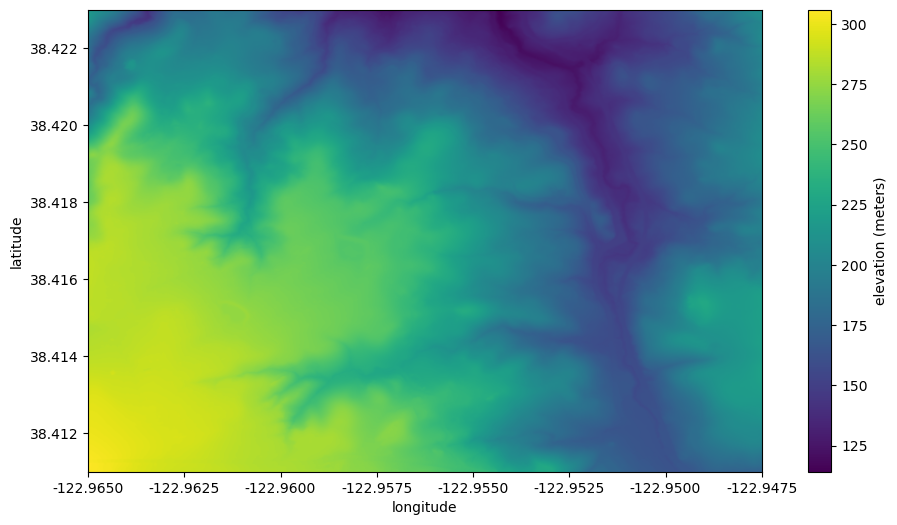

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))

cax = ax.imshow(elevation2022[row_min:row_max, col_min:col_max], extent=EXTENT)
fig.colorbar(cax, label="elevation (meters)", ax=ax)

axis_labels(ax)

None

This is the local elevation. (Previous studies used this directly as a gully detector, but it has false positives on isolated, non-trough holes.)

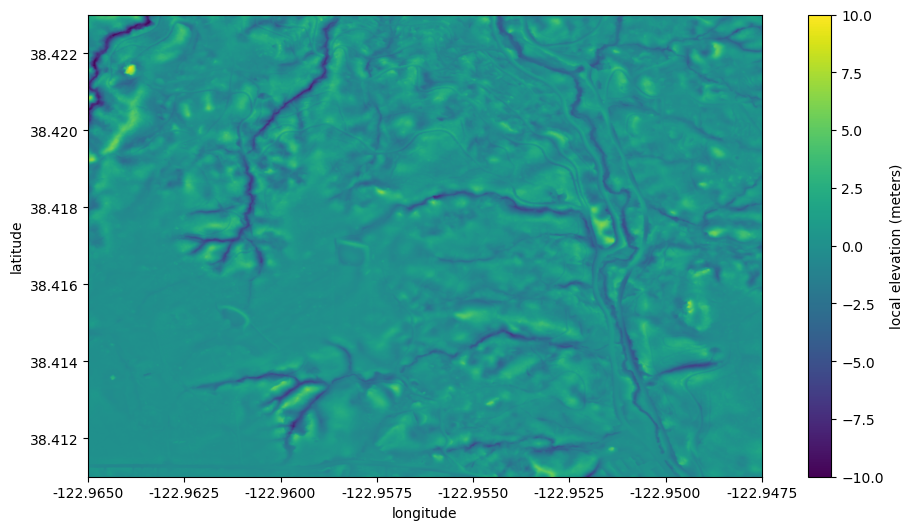

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

cax = ax.imshow(local_elevation2022[row_min:row_max, col_min:col_max], extent=EXTENT, vmin=-10, vmax=10)
fig.colorbar(cax, label="local elevation (meters)", ax=ax)

axis_labels(ax)

None

This is the result of gully detection using a 40 meter gully trough convolution kernel. It's less noisy, preferentially picking out long, skinny troughs over isolated holes.

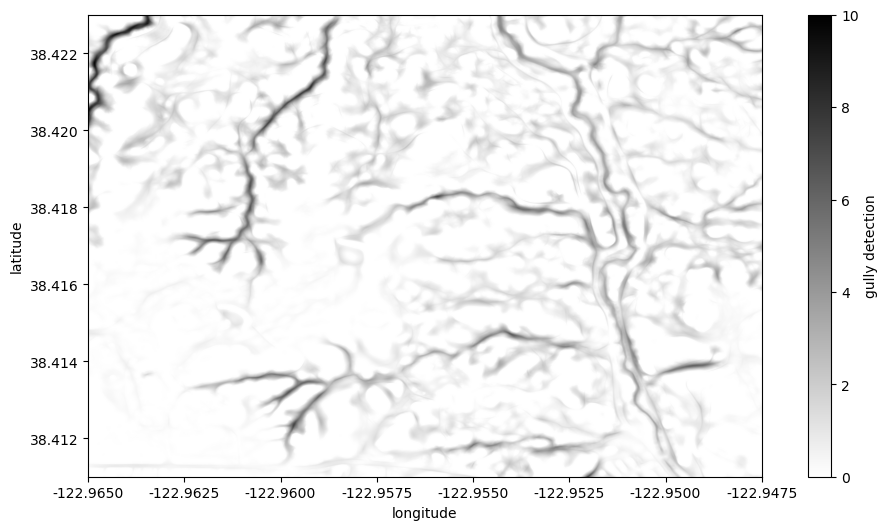

In [132]:
fig, ax = plt.subplots(figsize=(12, 6))

cax = ax.imshow(gullies2022[row_min:row_max, col_min:col_max], extent=EXTENT, cmap="gray_r", vmin=0, vmax=10)
fig.colorbar(cax, label="gully detection", ax=ax)

axis_labels(ax)

None

Here are changes in elevation from 2013 to 2022 (negative means lower in 2022).

(The blue in the lower left is a bit outside of the 2013 mask.)

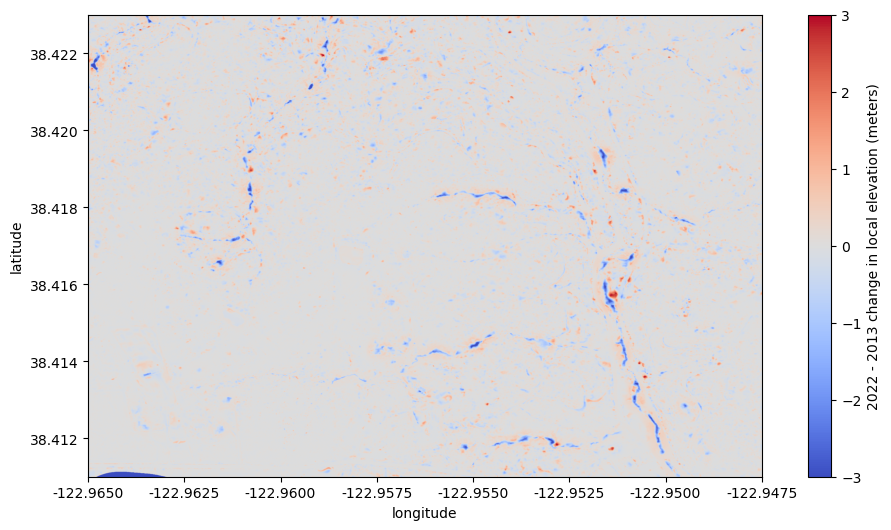

In [145]:
fig, ax = plt.subplots(figsize=(12, 6))

cax = ax.imshow(elevation_change[row_min:row_max, col_min:col_max], extent=EXTENT, vmin=-3, vmax=3, cmap="coolwarm")
fig.colorbar(cax, label="2022 - 2013 change in local elevation (meters)", ax=ax)

axis_labels(ax)

None

Here are changes in elevation in gullies (change in elevation × gully score, which is 10 or more in a gully).

These are preferentially negative (gullies excavate).

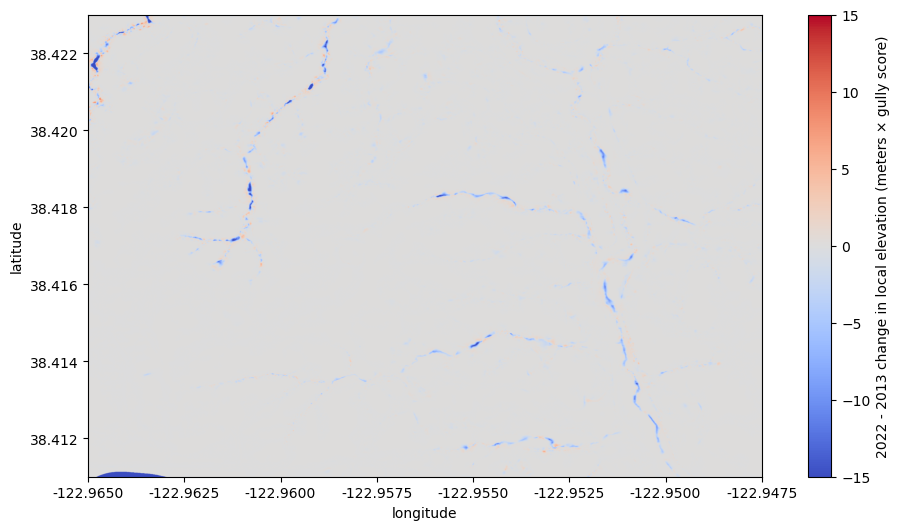

In [150]:
fig, ax = plt.subplots(figsize=(12, 6))

cax = ax.imshow(elevation_change_in_gullies[row_min:row_max, col_min:col_max], extent=EXTENT, vmin=-15, vmax=15, cmap="coolwarm")
fig.colorbar(cax, label="2022 - 2013 change in local elevation (meters \u00d7 gully score)", ax=ax)

axis_labels(ax)

None

The elevation maxima (alerts) are points of extreme erosion in gullies.

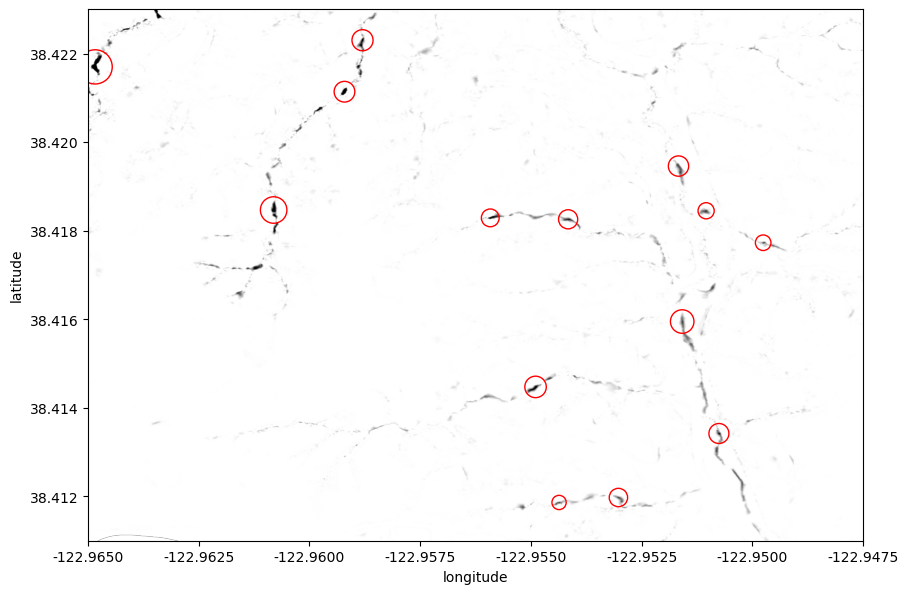

In [269]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.imshow(-elevation_change_in_gullies[row_min:row_max, col_min:col_max], extent=EXTENT, vmin=0, vmax=15, cmap="gray_r")

ax.scatter(longitudes, latitudes, marker="o", edgecolor="red", facecolor="none", s=scores * 500)

ax.set_xlim(LNG_MIN, LNG_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)

axis_labels(ax)

None

Next, let's zoom in on a site of deep erosion (in the gully Brock talked about in the neighbor to the west of OAEC).

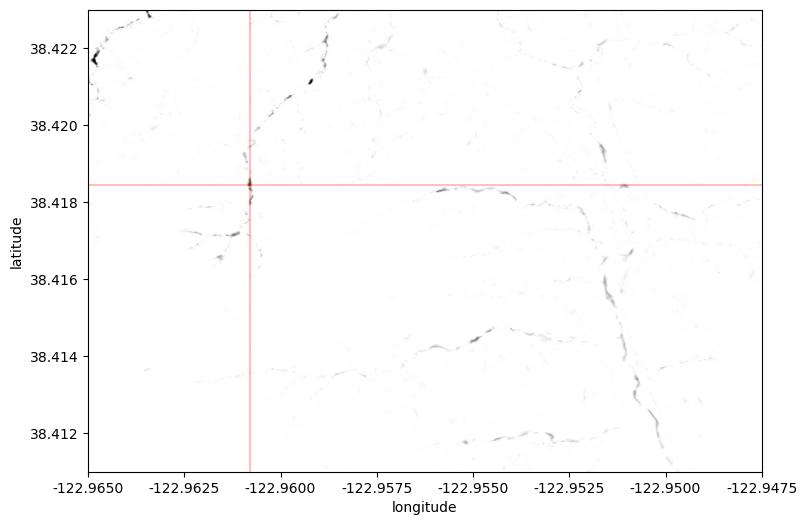

In [25]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.imshow(elevation_change_in_gullies[row_min:row_max, col_min:col_max], extent=EXTENT, vmin=-30, vmax=0, cmap="gray")
axis_labels(ax)

target_lng = -122.9608
target_lat = 38.41845
ax.axvline(target_lng, c="red", alpha=0.25)
ax.axhline(target_lat, c="red", alpha=0.25)

(target_east,), (target_north,) = rasterio.warp.transform(
    "EPSG:4326",
    crs,
    [target_lng],
    [target_lat],
)

margin = 100
h_col, h_row_low = rasterio.transform.rowcol(transform, target_east - margin, target_north)
h_col, h_row_high = rasterio.transform.rowcol(transform, target_east + margin, target_north)
v_col_high, v_row = rasterio.transform.rowcol(transform, target_east, target_north - margin)
v_col_low, v_row = rasterio.transform.rowcol(transform, target_east, target_north + margin)

The east-west line is perpendicular to this gully (which is flowing south). Here is its elevation profile for both years.

Outside the gully, the elevation profile matches well between the two years, but not inside it.

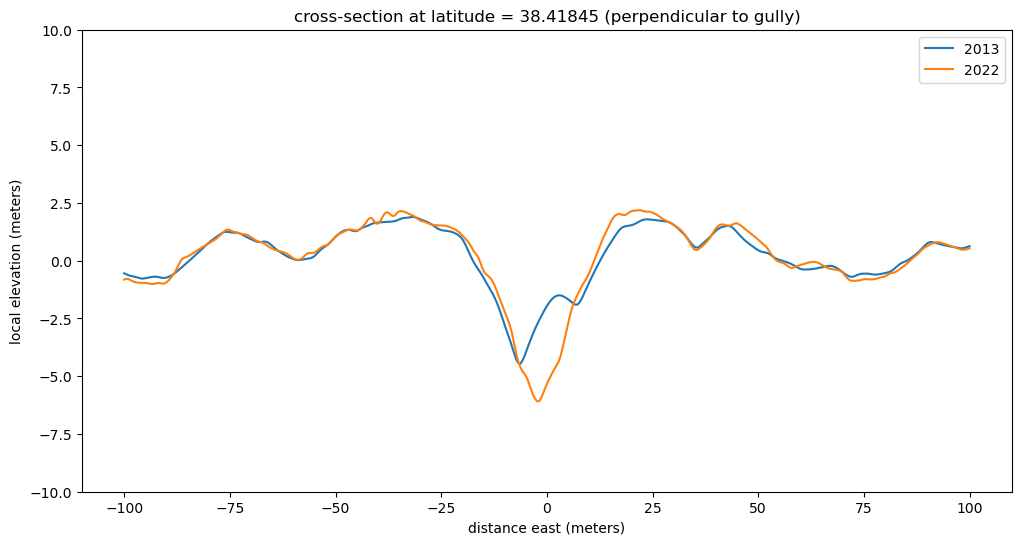

In [26]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.linspace(-margin, margin, h_row_high - h_row_low)

ax.plot(x, local_elevation2013[h_col, h_row_low : h_row_high], label="2013")
ax.plot(x, local_elevation2022[h_col, h_row_low : h_row_high], label="2022")

ax.legend()

ax.set_title(f"cross-section at latitude = {target_lat} (perpendicular to gully)")
ax.set_xlabel("distance east (meters)")
ax.set_ylim(-10, 10)
ax.set_ylabel("local elevation (meters)")

None

Here's an elevation profile along the north-south line, which is—roughly—along the gully.

In some regions (outside the gully? hard to say...) the elevation profile lines up well, but inside there are eroded clumps.

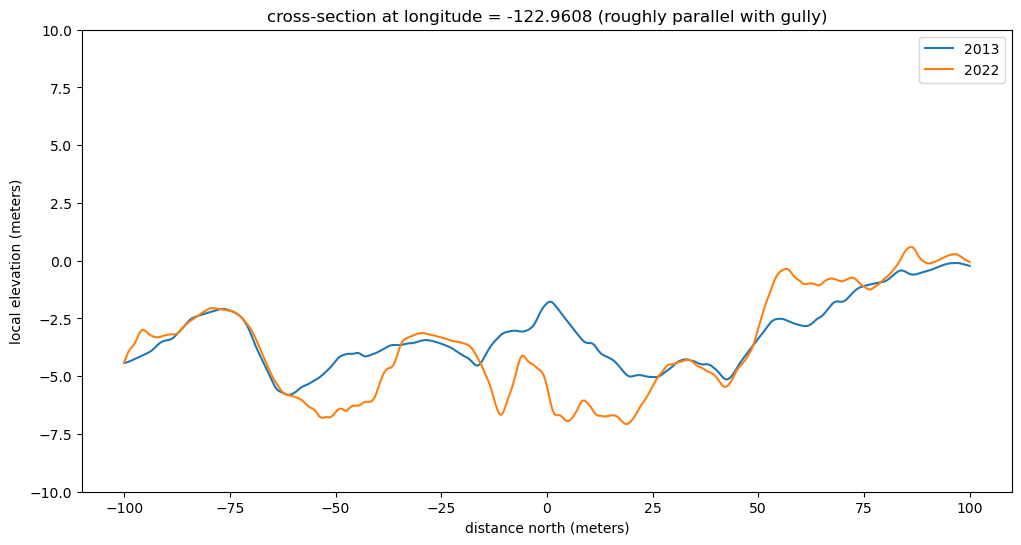

In [27]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.linspace(-margin, margin, v_col_high - v_col_low)

ax.plot(x, local_elevation2013[v_col_low : v_col_high, v_row][::-1], label="2013")
ax.plot(x, local_elevation2022[v_col_low : v_col_high, v_row][::-1], label="2022")

ax.legend()

ax.set_title(f"cross-section at longitude = {target_lng} (roughly parallel with gully)")
ax.set_xlabel("distance north (meters)")
ax.set_ylim(-10, 10)
ax.set_ylabel("local elevation (meters)")

None